# Modelos econométricos clásicos: ARIMA univariante y SARIMAX

Primer cuaderno de modelado. Además de sus propios modelos, fija las dos referencias que el resto
de cuadernos cargan para compararse: el **suelo** (paseo aleatorio) y el **benchmark** (ARIMA
univariante). Ambos se calculan aquí una sola vez y se guardan en `Resultados/`.

**Estructura del cuaderno.** (1) Datos y exploración de la serie. (2) Esquema de validación, el
expanding window que sostiene todo. (3) Hiperparámetros y optimización, donde se documenta el
gridsearch sin fuga. (4) Suelo de paseo aleatorio. (5) Benchmark ARIMA. (6) SARIMAX con selección
embebida de exógenas. (7) Comparativa y stress-test COVID. (8) Evolución esperada del paro. (9)
Cierre.

## Cómo funciona un modelo ARIMA

Un modelo ARIMA explica una serie temporal a partir de su propia historia, combinando tres
mecanismos. El componente autorregresivo (AR, orden p) hace que el valor de hoy dependa de sus
valores pasados: recoge la inercia, la tendencia de la serie a prolongar su nivel reciente. El
componente de integración (I, orden d) es el número de diferencias necesarias para que la serie sea
estacionaria, es decir, para que su media y su varianza no dependan del momento del tiempo. El
componente de media móvil (MA, orden q) hace que el valor de hoy dependa de los errores de
predicción recientes, de modo que un shock puntual se propaga y se amortigua a lo largo de varios
periodos. La notación compacta es ARIMA(p, d, q).

Cuando la serie tiene un patrón que se repite cada s periodos, la extensión estacional SARIMA añade
un segundo bloque (P, D, Q) que opera sobre el rezago estacional. Para datos trimestrales s es igual
a 4, así que el modelo aprende tanto la dinámica de un trimestre al siguiente como la relación de
cada trimestre con el mismo trimestre del año anterior.

SARIMAX añade la X de variables exógenas: es una regresión sobre regresores externos cuyo término de
error sigue una estructura ARMA. La parte sistemática captura el efecto de las variables
explicativas (actividad, crédito, precios) y la estructura ARMA absorbe la autocorrelación que esos
regresores no explican, evitando inferencia espuria.

## Por qué se ajusta al desempleo

La tasa de paro española es una de las series más persistentes del cuadro macroeconómico: tras una
recesión el desempleo tarda años en reabsorberse, un rasgo asociado a la histéresis y a la dualidad
del mercado laboral. Esa persistencia es justo lo que captura el componente autorregresivo, y hace
del paseo aleatorio un suelo exigente, no un rival trivial. Los grandes shocks, de la reconversión
industrial a la crisis financiera o a la COVID, entran como innovaciones que el término de media
móvil propaga de manera gradual. La estacionalidad trimestral, ligada a las campañas agrícola y
turística y al calendario de la EPA, se recoge con el bloque estacional. Por último, las variables
exógenas aportan la información adelantada que la propia serie no contiene: la brecha de producción
articula la ley de Okun, el crédito anticipa el ciclo de inversión y empleo, y los precios señalan
los shocks de oferta.

## 1. Datos y exploración de la serie

Se consume `Datasets Modelado/econometricos_estacionario_modelado.csv`, ya alineado por
disponibilidad de publicación en el panel de variables. El objetivo, la tasa de paro total, entra en
nivel por ser estacionario en nivel según el análisis del panel; los regresores entran en su forma
estacionaria. El cuaderno no reaplica rezagos de disponibilidad: únicamente adelanta el objetivo
según el horizonte de pronóstico.

In [1]:
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.seasonal import STL

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.width", 120)

RAIZ = Path.cwd().parent if Path.cwd().name == "Modelos" else Path.cwd()
RUTA_DATOS = RAIZ / "Datasets Modelado" / "econometricos_estacionario_modelado.csv"
RUTA_RESULTADOS = RAIZ / "Resultados"
RUTA_RESULTADOS.mkdir(exist_ok=True)

TARGET = "tasa_paro_total"
DUMMY = "dummy_2020Q2"
HORIZONTES = [0, 1, 2, 3, 4]          # 0 = nowcast, 1..4 = trimestres adelante
M_ESTACIONAL = 4

PRIMER_TEST = "1996Q1"                 # primer trimestre nowcast del expanding window
K_ORDEN = 6                            # cada cuantos folds se rebusca el orden ARIMA
K_SEL = 4                             # cada cuantos folds se reselecciona el conjunto de exogenas

# Topes del gridsearch ARIMA (parsimonia a priori para el tamano muestral); d=0 porque el panel
# cierra que el paro es estacionario en nivel; la diferenciacion estacional D la decide un test STL.
P_CAP, Q_CAP, SP_CAP, SQ_CAP = 4, 3, 1, 2
RANGO_PLAUSIBLE = (0.0, 60.0)          # guarda de estabilidad: la tasa de paro vive aqui
MARGEN_SALTO = 2.0                     # guarda de salto: multiplo del maximo cambio historico permitido

# Seleccion de exogenas del SARIMAX
NUCLEO_ECONOMICO = ["brecha_output_hp", "crecimiento_credito_yoy", "inflacion_qoq"]
K_MAX_EXOG = 4
VIF_UMBRAL = 10.0

# Paleta
C = {"real": "#1f2a44", "rw": "#9aa6b2", "arima": "#2e7d32", "sarimax": "#e8731a",
     "band": "#e8731a", "corte": "#78909C"}

In [2]:
df = pd.read_csv(RUTA_DATOS, parse_dates=["fecha"]).sort_values("fecha").reset_index(drop=True)
df = df.set_index(pd.PeriodIndex(df["fecha"].dt.to_period("Q"))).drop(columns=["fecha"])

y = df[TARGET]
X_all = df.drop(columns=[TARGET])
print(f"Observaciones: {len(df)}  |  rango: {df.index[0]} a {df.index[-1]}")
print(f"Regresores disponibles: {X_all.shape[1]} (incluida {DUMMY})")
print(f"Valores ausentes en el objetivo: {int(y.isna().sum())}")
df[[TARGET]].describe().T

Observaciones: 198  |  rango: 1976Q3 a 2025Q4
Regresores disponibles: 56 (incluida dummy_2020Q2)
Valores ausentes en el objetivo: 0


,count,mean,std,min,25%,50%,75%,max
tasa_paro_total,198.0,15.474281,5.061456,4.406605,11.399926,15.478742,19.578301,26.935354


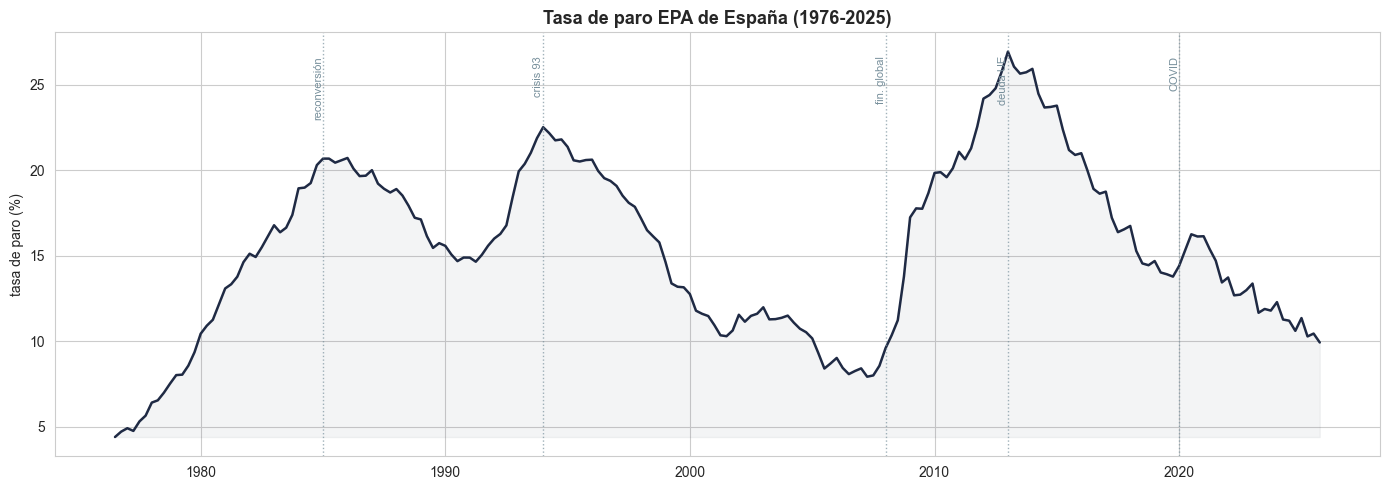

In [3]:
# Trayectoria historica del paro con los grandes shocks del periodo
fechas = y.index.to_timestamp()
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(fechas, y.values, color=C["real"], lw=1.8)
ax.fill_between(fechas, y.values, y.min(), color=C["real"], alpha=0.05)
for anio, txt in [(1985, "reconversión"), (1994, "crisis 93"), (2008, "fin. global"),
                  (2013, "deuda UE"), (2020, "COVID")]:
    x = pd.Timestamp(f"{anio}-01-01")
    ax.axvline(x, color=C["corte"], ls=":", lw=1, alpha=0.7)
    ax.text(x, y.max() * 0.99, txt, rotation=90, va="top", ha="right", fontsize=8, color=C["corte"])
ax.set_title("Tasa de paro EPA de España (1976-2025)", fontsize=13, fontweight="bold")
ax.set_ylabel("tasa de paro (%)"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

## 2. Esquema de validación

La evaluación es un **expanding window** (validación walk-forward): el origen avanza un trimestre
cada vez y el conjunto de entrenamiento crece de forma acumulativa. No es una partición en bloques ni
un k-fold aleatorio, que romperían el orden temporal; cada predicción es estrictamente fuera de
muestra.

La tasa de paro de la EPA se publica con retardo, así que en cada origen el último dato observado es
el del trimestre anterior. Desde ahí se predicen cinco puntos: el **nowcast** (h=0), el trimestre en
curso aún no publicado, y los cuatro trimestres siguientes (h=1..4). Los folds son **idénticos para
los tres modelos** y reutilizables por el resto de cuadernos.

Cada modelo materializa el esquema de la forma que le es natural, siempre sin fuga:

- **Paseo aleatorio**: proyecta el último valor observado, plano para los cinco horizontes.
- **ARIMA univariante**: se estima con la historia del objetivo y se pronostica de forma iterada uno
  a cinco pasos.
- **SARIMAX**: pronóstico **directo** por horizonte. Para cada horizonte se adelanta el objetivo y se
  regresa sobre los regresores de la fila de origen, ya alineados por disponibilidad, sin proyectar
  exógenas a futuro. La dummy de la COVID viaja con el objetivo porque es una propiedad de la
  observación que se predice.

**Sin fuga.** Todo lo que se ajusta, el orden ARIMA y el conjunto de exógenas, se decide usando solo
el tramo de entrenamiento de cada fold; el punto de test nunca interviene en la elección del modelo.
Las métricas son RMSE y MAE por horizonte y globales, el `skill score` frente al paseo aleatorio y un
subperiodo COVID dedicado para el stress-test.

In [4]:
def construir_folds(n, primer_tau, horizontes):
    """Lista de orígenes nowcast del expanding window que tienen el horizonte completo disponible."""
    h_max = max(horizontes)
    return [tau for tau in range(primer_tau, n) if tau + h_max <= n - 1]


def idx_de(periodo):
    """Posición entera del trimestre indicado dentro del índice de la serie."""
    return df.index.get_loc(pd.Period(periodo, freq="Q"))


PRIMER_TAU = idx_de(PRIMER_TEST)
FOLDS = construir_folds(len(df), PRIMER_TAU, HORIZONTES)
print(f"Primer nowcast: {df.index[FOLDS[0]]}  |  último: {df.index[FOLDS[-1]]}  |  folds: {len(FOLDS)}")


def _rmse(e):
    """Raíz del error cuadrático medio de un vector de errores."""
    return float(np.sqrt(np.mean(np.square(e)))) if len(e) else float("nan")


def _mae(e):
    """Error absoluto medio de un vector de errores."""
    return float(np.mean(np.abs(e))) if len(e) else float("nan")


def metricas_desde_preds(preds, rmse_ref=None):
    """RMSE y MAE por horizonte, global y subperiodo COVID, más el skill score frente a la referencia."""
    out = {"por_horizonte": {}, "global": {}, "covid": {}}
    err = preds["y_real"] - preds["y_pred"]
    es_covid = preds["fecha"].astype(str).str.match(r"20(20|21)Q")
    for h in sorted(preds["horizonte"].unique()):
        m = preds["horizonte"] == h
        d = {"rmse": _rmse(err[m].to_numpy()), "mae": _mae(err[m].to_numpy()), "n": int(m.sum())}
        if rmse_ref is not None and rmse_ref.get(h):
            d["skill_vs_rw"] = float(1 - d["rmse"] / rmse_ref[h])
        out["por_horizonte"][str(h)] = d
        mc = m & es_covid
        out["covid"][str(h)] = {"rmse": _rmse(err[mc].to_numpy()), "mae": _mae(err[mc].to_numpy()),
                                "n": int(mc.sum())}
    out["global"] = {"rmse": _rmse(err.to_numpy()), "mae": _mae(err.to_numpy()), "n": int(len(err))}
    return out


def guardar(modelo, preds, metricas):
    """Escribe en Resultados/ las predicciones y las métricas de un modelo."""
    preds.to_csv(RUTA_RESULTADOS / f"preds_{modelo}.csv", index=False)
    with open(RUTA_RESULTADOS / f"metricas_{modelo}.json", "w", encoding="utf-8") as f:
        json.dump(metricas, f, ensure_ascii=False, indent=2)


def cota_salto(endog, h_max, margen=MARGEN_SALTO):
    """Cota por horizonte del salto admisible respecto al último valor: el mayor cambio a (h+1)
    pasos visto en el entrenamiento, escalado. Acota extrapolaciones absurdas sin mirar el test."""
    arr = np.asarray(endog)
    cotas = []
    for h in range(h_max + 1):
        if len(arr) > h + 1:
            d = np.abs(arr[h + 1:] - arr[:-(h + 1)])
            cotas.append(margen * float(np.nanmax(d)) if d.size else np.inf)
        else:
            cotas.append(np.inf)
    return cotas


def es_inestable(pred, ultimo, cota):
    """True si un pronóstico es no finito, sale del rango plausible o salta más que la cota."""
    return (not np.isfinite(pred) or pred < RANGO_PLAUSIBLE[0] or pred > RANGO_PLAUSIBLE[1]
            or abs(pred - ultimo) > cota)


def tabla_horizontes(met):
    """DataFrame resumen de RMSE, MAE, skill y RMSE-COVID por horizonte para presentación."""
    filas = []
    for h in HORIZONTES:
        d = met["por_horizonte"][str(h)]
        fila = {"horizonte": h, "rmse": round(d["rmse"], 4), "mae": round(d["mae"], 4)}
        for clave in ("skill_vs_rw", "skill_vs_arima"):
            if clave in d:
                fila[clave] = round(d[clave], 3)
        fila["covid_rmse"] = round(met["covid"][str(h)]["rmse"], 4)
        filas.append(fila)
    return pd.DataFrame(filas).set_index("horizonte")

Primer nowcast: 1996Q1  |  último: 2024Q4  |  folds: 116


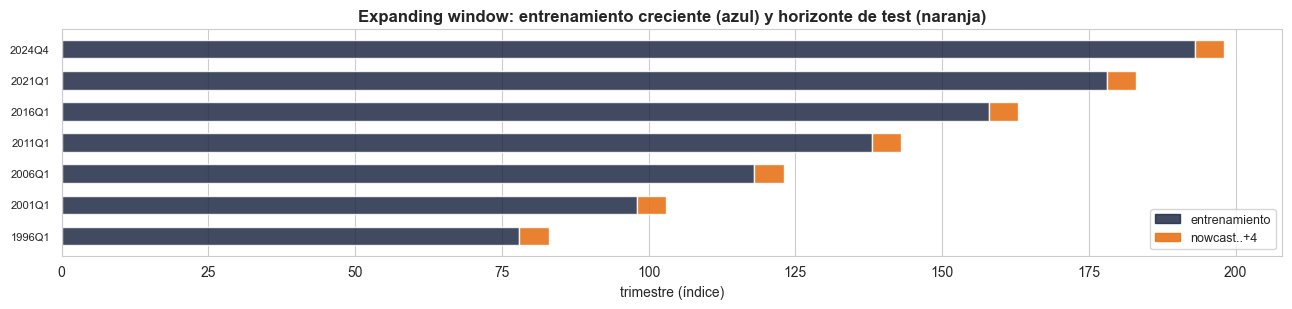

In [5]:
# Esquema visual del expanding window: el entrenamiento (azul) crece y el test (naranja) avanza
fig, ax = plt.subplots(figsize=(13, 3.2))
muestra = FOLDS[::20] + [FOLDS[-1]]
for i, tau in enumerate(muestra):
    ax.barh(i, tau, left=0, color=C["real"], alpha=0.85, height=0.6)
    ax.barh(i, 5, left=tau, color=C["sarimax"], alpha=0.9, height=0.6)
    ax.text(-2, i, str(df.index[tau]), ha="right", va="center", fontsize=8)
ax.set_yticks([]); ax.set_xlabel("trimestre (índice)")
ax.set_title("Expanding window: entrenamiento creciente (azul) y horizonte de test (naranja)",
             fontsize=12, fontweight="bold")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=C["real"], alpha=0.85),
                   plt.Rectangle((0, 0), 1, 1, color=C["sarimax"], alpha=0.9)],
          labels=["entrenamiento", "nowcast..+4"], loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

In [6]:
# Funciones de grafico reutilizables: mismas para los tres modelos, para homogeneizar la presentacion
PRIMER_TS = df.index[FOLDS[0]].to_timestamp()          # frontera entrenamiento / test (primer nowcast)


def plot_backtest(preds, nombre, color):
    """Backtest del nowcast sobre el historico completo: entrenamiento sombreado, test con prediccion y banda de error empirica."""
    s = preds[preds["horizonte"] == 0].sort_values("fecha")
    ejex = pd.PeriodIndex(s["fecha"].values, freq="Q").to_timestamp()
    pred = s["y_pred"].to_numpy()
    resid = (s["y_real"] - s["y_pred"]).to_numpy()
    rmse = _rmse(resid)
    sigma = pd.Series(resid).rolling(8, min_periods=3).std().bfill().to_numpy()  # volatilidad local (regime-aware)
    f_all = y.index.to_timestamp()

    fig, ax = plt.subplots(figsize=(14, 4.8))
    ax.axvspan(f_all[0], PRIMER_TS, color="0.5", alpha=0.07)                       # entrenamiento (sin prediccion OOS)
    ax.plot(f_all, y.values, color=C["real"], lw=1.7, label="Real", zorder=3)      # serie completa 1976-2025
    ax.fill_between(ejex, pred - 1.96 * sigma, pred + 1.96 * sigma, color=color,    # banda de error empirica al 95% (gaussiana sobre residuos)
                    alpha=0.18, label="banda de error 95% (volatilidad local)")
    ax.plot(ejex, pred, color=color, lw=1.5, ls="--", label=f"{nombre} (nowcast OOS)", zorder=4)
    ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2021-12-31"), color="red", alpha=0.06)  # COVID
    ax.text(f_all[0], y.max() * 0.99, "  entrenamiento", color="0.4", fontsize=8.5, va="top")
    ax.text(PRIMER_TS, y.max() * 0.99, "  test (1996-2024)", color="0.4", fontsize=8.5, va="top")
    ax.set_title(f"Backtest del nowcast: {nombre}   |   RMSE OOS = {rmse:.3f}", fontsize=12, fontweight="bold")
    ax.set_ylabel("tasa de paro (%)"); ax.set_xlabel(""); ax.legend(fontsize=8.5, loc="upper right", ncol=2)
    plt.tight_layout(); plt.show()


def plot_rmse_horizonte(modelos):
    """RMSE por horizonte de varios modelos en un unico grafico a ancho completo (la comparacion aporta aqui)."""
    fig, ax = plt.subplots(figsize=(14, 4.5))
    for nombre, met, color in modelos:
        ax.plot(HORIZONTES, [met["por_horizonte"][str(h)]["rmse"] for h in HORIZONTES],
                marker="o", lw=2, label=nombre, color=color)
    ax.set_xlabel("horizonte (0 = nowcast, 4 = un ano vista)"); ax.set_ylabel("RMSE (puntos de paro)")
    ax.set_xticks(HORIZONTES); ax.set_title("RMSE por horizonte de pronostico", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9); plt.tight_layout(); plt.show()


def plot_errores(modelos, horizonte=0):
    """Error de pronostico en el tiempo (real - prediccion, OOS): muestra donde falla cada modelo y que los errores son reales (no hay sobreajuste)."""
    fig, ax = plt.subplots(figsize=(14, 4.5))
    base = modelos[0][1]
    s0 = base[base["horizonte"] == horizonte].sort_values("fecha")
    ejex = pd.PeriodIndex(s0["fecha"].values, freq="Q").to_timestamp()
    ax.axhline(0, color="0.5", lw=1)
    ax.axvspan(pd.Timestamp("2008-07-01"), pd.Timestamp("2009-07-01"), color="grey", alpha=0.08)   # crisis 2008
    ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2021-12-31"), color="red", alpha=0.07)     # COVID
    for nombre, preds, color in modelos:
        s = preds[preds["horizonte"] == horizonte].sort_values("fecha")
        err = (s["y_real"] - s["y_pred"]).to_numpy()
        ax.plot(ejex, err, color=color, lw=1.3, alpha=0.9, label=f"{nombre} (RMSE {_rmse(err):.2f})")
    ax.set_title("Error de pronostico en el tiempo (real - prediccion, nowcast OOS)", fontsize=12, fontweight="bold")
    ax.set_ylabel("error (puntos de paro)"); ax.set_xlabel(""); ax.legend(fontsize=9, ncol=len(modelos), loc="lower left")
    plt.tight_layout(); plt.show()

## 3. Hiperparámetros y optimización del ARIMA

El orden del modelo, `(p, d, q)(P, D, Q)` con periodo 4, se busca minimizando el **AICc**, criterio
corregido para muestras pequeñas. La búsqueda se realiza **dentro de cada fold con solo su tramo de
entrenamiento**, nunca sobre la serie completa ni mirando el test, así que no introduce fuga.

La configuración del gridsearch responde a una lección que conviene explicitar. Una rejilla muy
ancha, combinada con la minimización de un criterio en muestra, no garantiza el mejor pronóstico: en
las ventanas cortas el AICc llega a elegir órdenes de orden alto que ajustan bien en muestra pero
**explotan** al pronosticar. Por eso la búsqueda se acota de tres maneras, todas justificadas a
priori y no por inspección del test:

- **`d = 0` fijo**: el panel ya cierra que la tasa de paro es estacionaria en nivel, I(0). La
  diferenciación estacional `D` la decide un test de fuerza estacional STL.
- **Topes de parsimonia** apropiados al tamaño muestral: `p` hasta 4, `q` hasta 3, `P` hasta 1, `Q`
  hasta 2.
- **Búsqueda coarse-to-fine**: una malla gruesa localiza la región y un refino de paso uno la afina,
  lo que cubre el espacio con pocas decenas de ajustes por fold en vez de cientos.
- **Guarda de estabilidad**: se rechaza cualquier pronóstico no finito, fuera del rango plausible de
  una tasa de paro, o que se aleje del último valor observado más de lo que la serie se ha movido
  históricamente en ese horizonte (cota calibrada solo con el entrenamiento). El punto afectado cae a
  un fallback robusto, el último valor observado. Esto acota las extrapolaciones absurdas que un
  ajuste sobre una ventana corta puede producir, sin mirar el test.

In [7]:
def determinar_D(serie, m=M_ESTACIONAL):
    """Diferenciación estacional (0 o 1) según la fuerza estacional de una descomposición STL."""
    s = serie.dropna()
    if len(s) < 2 * m + 1:
        return 0
    try:
        res = STL(s.values, period=m, robust=True).fit()
        var_sr = np.var(res.seasonal + res.resid)
        fs = max(0.0, 1 - np.var(res.resid) / var_sr) if var_sr > 0 else 0.0
        return 1 if fs > 0.64 else 0          # umbral Wang-Smyth-Hyndman
    except Exception:
        return 0


def _aicc(res, nobs):
    """AICc (AIC corregido para muestra pequeña) de un modelo ya ajustado."""
    k = res.df_model + 1
    den = nobs - k - 1
    return res.aic + (2 * k * (k + 1) / den) if den > 0 else np.inf


def ajustar_sarimax(endog, exog, order, seasonal_order, trend, enforce=True):
    """Ajusta un SARIMAX por máxima verosimilitud (estacionariedad/invertibilidad forzadas)."""
    mod = SARIMAX(endog, exog=exog, order=order, seasonal_order=seasonal_order, trend=trend,
                  enforce_stationarity=enforce, enforce_invertibility=enforce)
    return mod.fit(disp=False, maxiter=200)


def _aicc_orden(endog, order, seas, trend):
    """AICc de un orden candidato; devuelve infinito si el ajuste falla o es inestable."""
    try:
        c = _aicc(ajustar_sarimax(endog, None, order, seas, trend), len(endog))
        return c if np.isfinite(c) else np.inf
    except Exception:
        return np.inf


def buscar_orden(endog):
    """Selecciona el orden por AICc con búsqueda coarse-to-fine, usando solo el tramo de train."""
    d = 0
    D = determinar_D(endog)
    trend = "c" if D == 0 else "n"

    def mejor_en(combos):
        mejor = (np.inf, None, None)
        for p, q, P, Q in combos:
            seas = (P, D, Q, M_ESTACIONAL)
            c = _aicc_orden(endog, (p, d, q), seas, trend)
            if c < mejor[0]:
                mejor = (c, (p, d, q), seas)
        return mejor

    coarse = [(p, q, P, Q) for p in (0, 2, 4) for q in (0, 2) for P in (0, 1) for Q in (0, 2)]
    _, order, seas = mejor_en(coarse)
    if order is None:
        return (1, 0, 0), (0, D, 0, M_ESTACIONAL), trend
    p0, q0, P0, Q0 = order[0], order[2], seas[0], seas[2]
    fino = [(p, q, P, Q)
            for p in range(max(0, p0-1), min(P_CAP, p0+1)+1)
            for q in range(max(0, q0-1), min(Q_CAP, q0+1)+1)
            for P in range(max(0, P0-1), min(SP_CAP, P0+1)+1)
            for Q in range(max(0, Q0-1), min(SQ_CAP, Q0+1)+1)]
    _, order, seas = mejor_en(fino)
    return order, seas, trend

In [8]:
# El gridsearch EN ACCIÓN sobre el primer fold, usando solo su tramo de entrenamiento (sin fuga):
# se muestra la malla gruesa rankeada por AICc y el orden que la búsqueda acaba eligiendo.
endog_demo = y.iloc[:FOLDS[0]]
D_demo = determinar_D(endog_demo)
ranking = []
for p in (0, 2, 4):
    for q in (0, 2):
        for P in (0, 1):
            for Q in (0, 2):
                seas = (P, D_demo, Q, M_ESTACIONAL)
                ranking.append({"order": (p, 0, q), "seasonal": seas,
                                "aicc": round(_aicc_orden(endog_demo, (p, 0, q), seas, "c"), 2)})
ranking = pd.DataFrame(ranking).sort_values("aicc").reset_index(drop=True)
print(f"Fold 0, entrenamiento {df.index[0]} a {df.index[FOLDS[0]-1]}  (D={D_demo})")
print(f"Orden elegido por coarse-to-fine: {buscar_orden(endog_demo)[:2]}")
print("\nMalla gruesa rankeada por AICc (solo train):")
ranking.head(8)

Fold 0, entrenamiento 1976Q3 a 1995Q4  (D=0)
Orden elegido por coarse-to-fine: ((2, 0, 1), (1, 0, 1, 4))

Malla gruesa rankeada por AICc (solo train):


,order,seasonal,aicc
0,"(2, 0, 0)","(1, 0, 2, 4)",82.05
1,"(2, 0, 0)","(1, 0, 0, 4)",87.28
2,"(4, 0, 2)","(0, 0, 2, 4)",91.50
3,"(4, 0, 2)","(0, 0, 0, 4)",91.54
4,"(2, 0, 0)","(0, 0, 2, 4)",96.69
5,"(4, 0, 0)","(0, 0, 2, 4)",96.76
6,"(2, 0, 2)","(1, 0, 0, 4)",97.63
7,"(2, 0, 2)","(1, 0, 2, 4)",100.12


### 3.1 Selección de modelo confirmada por validación temporal

El AICc elige el orden dentro de cada fold, pero conviene comprobar que esa elección se sostiene por
capacidad de pronóstico y no solo por ajuste en muestra. La tabla siguiente rankea órdenes candidatos
por su RMSE en una **validación temporal interna**, los trimestres de 1990 a 1995, estrictamente
anteriores al periodo de test que empieza en 1996, aplicando la misma guarda de estabilidad. No
interviene en la selección, que sigue siendo el AICc por fold, sino que confirma la lección de la
sección anterior: la familia de orden bajo con bloque estacional y `d = 0` domina con claridad,
mientras que el orden alto, que minimizaba el AICc en muestra, es el peor por capacidad de pronóstico.

In [9]:
# Confirmación de la elección por capacidad de pronóstico, no solo por AICc: se rankean órdenes
# candidatos por RMSE en una validación temporal interna (1990-1995, estrictamente anterior al test
# de 1996), aplicando la misma guarda de estabilidad. No selecciona el modelo (eso lo hace el AICc
# por fold); confirma que la familia de orden bajo domina a las alternativas de orden alto o con
# diferencias, que es la lección de esta sección.
CANDIDATOS_DEMO = {
    "(2,0,1)(1,0,1) familia elegida": ((2, 0, 1), (1, 0, 1, 4), "c"),
    "(2,0,0)(1,0,1)": ((2, 0, 0), (1, 0, 1, 4), "c"),
    "(3,0,1)(1,0,1)": ((3, 0, 1), (1, 0, 1, 4), "c"),
    "(1,0,3)(1,0,1)": ((1, 0, 3), (1, 0, 1, 4), "c"),
    "(1,0,0)(1,0,0) AR simple": ((1, 0, 0), (1, 0, 0, 4), "c"),
    "(6,0,0)(0,0,2) orden alto": ((6, 0, 0), (0, 0, 2, 4), "c"),
    "(0,1,1)(0,1,1) con diferencias": ((0, 1, 1), (0, 1, 1, 4), "n"),
}
val_ini, val_fin = idx_de("1990Q1"), idx_de("1994Q4")
filas_val = []
for nombre, (order, seas, trend) in CANDIDATOS_DEMO.items():
    err = []
    for tau in range(val_ini, val_fin + 1):
        endog = y.iloc[:tau]
        ult = float(endog.iloc[-1])
        cotas = cota_salto(endog, max(HORIZONTES))
        try:
            res = ajustar_sarimax(endog, None, order, seas, trend)
            fc = np.asarray(res.get_forecast(steps=max(HORIZONTES) + 1).predicted_mean)
        except Exception:
            fc = np.repeat(ult, max(HORIZONTES) + 1)
        for h in HORIZONTES:
            pred = ult if es_inestable(fc[h], ult, cotas[h]) else float(fc[h])
            err.append(float(y.iloc[tau + h]) - pred)
    filas_val.append({"orden": nombre, "rmse_validacion": round(_rmse(np.array(err)), 3)})
pd.DataFrame(filas_val).sort_values("rmse_validacion").reset_index(drop=True)

,orden,rmse_validacion
0,"(1,0,3)(1,0,1)",1.553
1,"(2,0,0)(1,0,1)",1.562
2,"(2,0,1)(1,0,1) familia elegida",1.666
3,"(3,0,1)(1,0,1)",1.681
4,"(1,0,0)(1,0,0) AR simple",1.753
5,"(0,1,1)(0,1,1) con diferencias",2.020
6,"(6,0,0)(0,0,2) orden alto",2.054


## 4. Suelo: paseo aleatorio

El paseo aleatorio sin deriva pronostica `y_{t+h} = y_{t-1}` para todos los horizontes, donde
`y_{t-1}` es el último valor publicado en el origen. Por la fuerte persistencia del paro es un suelo
exigente: cualquier modelo debe justificar su complejidad batiéndolo.

In [10]:
def correr_random_walk(folds, horizontes):
    """Genera las predicciones del paseo aleatorio (último valor publicado, plano en el horizonte)."""
    filas = []
    for fold, tau in enumerate(folds):
        ultimo = float(y.iloc[tau - 1])
        for h in horizontes:
            filas.append({"fecha": str(df.index[tau + h]), "y_real": float(y.iloc[tau + h]),
                          "y_pred": ultimo, "horizonte": h, "fold": fold})
    return pd.DataFrame(filas)


preds_rw = correr_random_walk(FOLDS, HORIZONTES)
met_rw = metricas_desde_preds(preds_rw)
RMSE_RW = {h: met_rw["por_horizonte"][str(h)]["rmse"] for h in HORIZONTES}
guardar("random_walk", preds_rw, met_rw)
tabla_horizontes(met_rw)

,rmse,mae,covid_rmse
horizonte,,,
0,0.7826,0.5765,0.7707
1,1.3297,1.0068,1.2788
2,1.7764,1.3986,1.6550
3,2.2048,1.7710,1.7800
4,2.7091,2.1717,1.7708


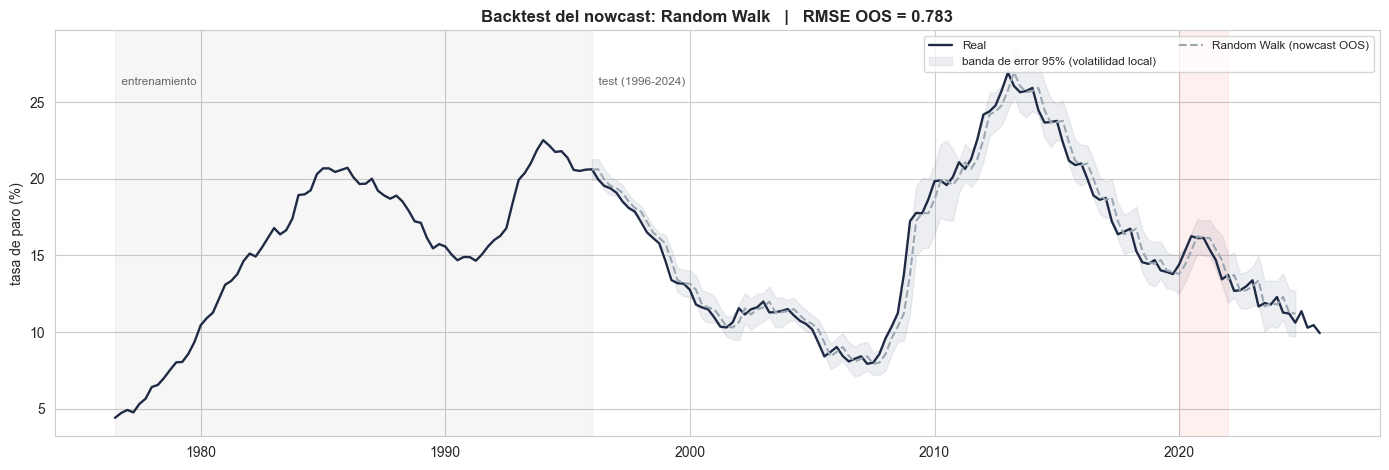

In [11]:
plot_backtest(preds_rw, "Random Walk", C["rw"])

## 5. Benchmark: ARIMA univariante

Con el `buscar_orden` de la sección 3, el orden se reestima cada `K_ORDEN` folds sobre el
entrenamiento correspondiente y el pronóstico es iterado a cinco pasos. La guarda de estabilidad
sustituye por el último valor observado cualquier fold cuyo pronóstico se salga del rango plausible.

Este modelo es estrictamente univariante: no incorpora la dummy de la COVID, de modo que el atípico
de 2020 entra como un shock que el componente de media móvil arrastra. Esa contaminación, una vez
2020-Q2 forma parte del entrenamiento, es el contrapunto frente al SARIMAX, que sí la controla, y
alimenta el stress-test.

In [12]:
def correr_arima(folds, horizontes, k_orden=K_ORDEN):
    """Expanding window del ARIMA univariante: orden por AICc cada k_orden folds y forecast iterado."""
    h_max = max(horizontes)
    filas, ordenes, cache, guardas = [], [], None, 0
    for fold, tau in enumerate(folds):
        endog = y.iloc[:tau]
        if cache is None or fold % k_orden == 0:
            cache = buscar_orden(endog)
        order, seasonal, trend = cache
        ult = float(endog.iloc[-1])
        cotas = cota_salto(endog, h_max)
        try:
            res = ajustar_sarimax(endog, None, order, seasonal, trend)
            fc = np.asarray(res.get_forecast(steps=h_max + 1).predicted_mean)
        except Exception:
            fc = np.repeat(ult, h_max + 1)
        disparo = False
        for h in range(h_max + 1):                     # guarda de estabilidad por horizonte
            if es_inestable(fc[h], ult, cotas[h]):
                fc[h] = ult; disparo = True
        guardas += int(disparo)
        ordenes.append({"fold": fold, "tau": str(df.index[tau]), "order": order, "seasonal": seasonal})
        for h in horizontes:
            filas.append({"fecha": str(df.index[tau + h]), "y_real": float(y.iloc[tau + h]),
                          "y_pred": float(fc[h]), "horizonte": h, "fold": fold})
    print(f"guardas de estabilidad activadas: {guardas}/{len(folds)}")
    return pd.DataFrame(filas), pd.DataFrame(ordenes)


preds_ar, ordenes_ar = correr_arima(FOLDS, HORIZONTES)
met_ar = metricas_desde_preds(preds_ar, RMSE_RW)
met_ar["referencia_rw"] = {str(h): RMSE_RW[h] for h in HORIZONTES}
RMSE_AR = {h: met_ar["por_horizonte"][str(h)]["rmse"] for h in HORIZONTES}
guardar("arima", preds_ar, met_ar)

print("\nÓrdenes seleccionados a lo largo de los folds (frecuencia):")
print((ordenes_ar["order"].astype(str) + "x" + ordenes_ar["seasonal"].astype(str))
      .value_counts().to_string())
tabla_horizontes(met_ar)

guardas de estabilidad activadas: 1/116

Órdenes seleccionados a lo largo de los folds (frecuencia):
(2, 0, 1)x(1, 0, 1, 4)    48
(3, 0, 1)x(1, 0, 1, 4)    20
(2, 0, 0)x(1, 0, 1, 4)    18
(2, 0, 1)x(1, 0, 2, 4)    12
(3, 0, 1)x(1, 0, 2, 4)     6
(1, 0, 3)x(1, 0, 1, 4)     6
(2, 0, 0)x(1, 0, 2, 4)     6


,rmse,mae,skill_vs_rw,covid_rmse
horizonte,,,,
0,0.5242,0.3663,0.330,0.7682
1,0.9902,0.7012,0.255,1.7062
2,1.4138,1.0231,0.204,2.3371
3,1.7898,1.3236,0.188,2.7166
4,2.2951,1.7272,0.153,3.1346


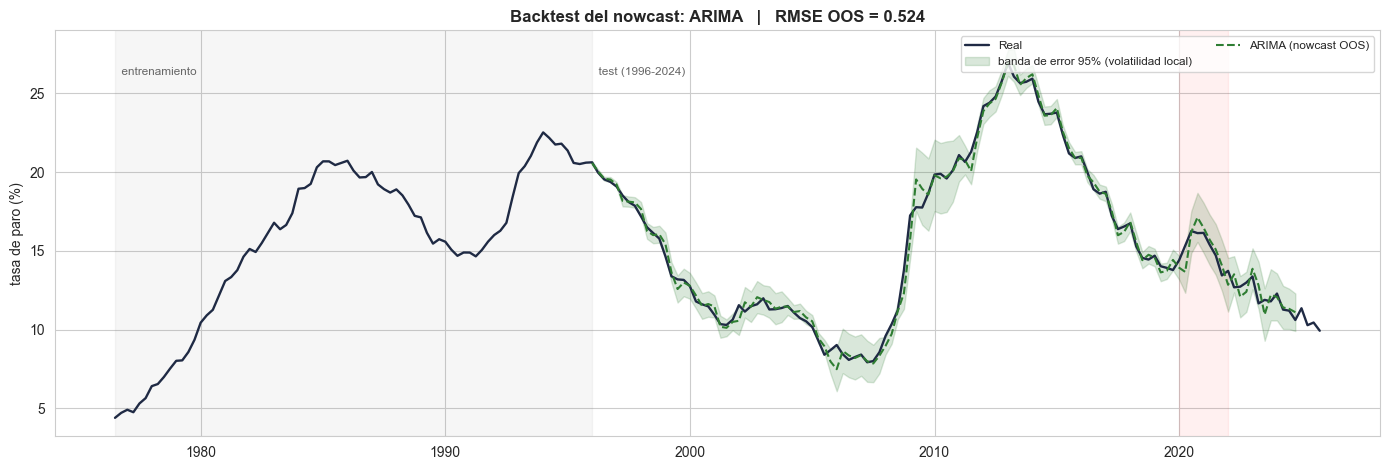

In [13]:
plot_backtest(preds_ar, "ARIMA", C["arima"])

**Lectura del ARIMA.** El orden seleccionado es estable en todo el expanding window: la búsqueda
elige ARIMA(2,0,1)(1,0,1) con periodo 4 en 48 de los 116 folds y se mueve dentro de una misma familia
parsimoniosa, ARMA de orden 2 o 3 con una media móvil corta y un bloque estacional (1,0,1) o (1,0,2),
en el resto. El grado de integración `d = 0` confirma el tratamiento del paro como serie estacionaria
en nivel. La guarda de estabilidad se activa en un solo fold de los 116, prueba de que la rejilla
acotada ya es intrínsecamente estable.

El benchmark bate al paseo aleatorio en todos los horizontes. La mejora de RMSE es del 33.0% en el
nowcast (0.524 frente a 0.783) y se modera hasta el 15.3% a cuatro trimestres (2.295 frente a 2.709).
Que la ventaja decrezca con el horizonte es coherente con la naturaleza del modelo: la inercia que
explota el componente autorregresivo es muy informativa a corto plazo y se diluye a medida que el
pronóstico se aleja del último dato. En el subperiodo COVID el ARIMA se degrada con fuerza, de 0.768
en el nowcast a 3.135 a cuatro trimestres, justo el comportamiento que se examina en el stress-test:
un atípico no controlado contamina el componente de media móvil de los folds posteriores.

## 6. SARIMAX con selección embebida de exógenas

La selección de regresores se realiza **dentro de cada fold y solo con su entrenamiento**. El
**núcleo económico** (brecha de producción, crédito e inflación) entra siempre como prior por canal
de transmisión. Sobre él se añaden hasta cuatro regresores por selección **forward** que minimiza el
AICc sobre la media condicional, con poda previa por factor de inflación de la varianza (VIF mayor
que 10). La dummy de 2020-Q2 se fuerza siempre como control del shock pasado. El conjunto se refresca
cada `K_SEL` folds.

El cribado forward se hace sobre la media condicional, rápido, y el modelo final se reestima como
SARIMAX completo con estructura ARMA reutilizando el orden del benchmark del fold. Las exógenas se
estandarizan con los estadísticos del entrenamiento, lo que estabiliza la estimación dado que
conviven regresores de escalas muy distintas. La frecuencia con la que cada variable se selecciona
documenta si el núcleo económico aguanta y si las señales marcadas como dudosas en el panel se
sostienen fuera de muestra.

In [14]:
def _ols_rss(X, y_):
    """Suma de cuadrados residual y número de parámetros de una regresión MCO con intercepto."""
    Xi = np.column_stack([np.ones(len(y_)), X]) if X.shape[1] else np.ones((len(y_), 1))
    beta = np.linalg.lstsq(Xi, y_, rcond=None)[0]
    r = y_ - Xi @ beta
    return float(r @ r), Xi.shape[1]


def _aicc_ols(X, y_):
    """AICc de una regresión MCO, criterio del cribado forward de exógenas."""
    rss, k = _ols_rss(X, y_)
    n = len(y_)
    if rss <= 0 or n <= k + 2:
        return np.inf
    ll = -0.5 * n * (np.log(2 * np.pi * rss / n) + 1)
    p = k + 1
    return -2 * ll + 2 * p + 2 * p * (p + 1) / (n - p - 1)


def _vif(Xtr, otras, c):
    """Factor de inflación de la varianza del candidato c frente al conjunto ya elegido."""
    if not otras:
        return 1.0
    sub = pd.concat([Xtr[c].rename("c"), Xtr[otras]], axis=1).dropna()
    if len(sub) < len(otras) + 3 or sub["c"].std() == 0:
        return np.inf
    rss, _ = _ols_rss(sub[otras].to_numpy(), sub["c"].to_numpy())
    tss = float(((sub["c"] - sub["c"].mean()) ** 2).sum())
    r2 = 1 - rss / tss if tss > 0 else 1.0
    return 1.0 / (1.0 - r2) if r2 < 1 else np.inf


def seleccionar_exog(Xtr, ytr, dummy_ok, candidatos, k_max=K_MAX_EXOG, vif_umbral=VIF_UMBRAL):
    """Selección forward por AICc sobre la media condicional; núcleo y dummy forzados, poda VIF."""
    base = [c for c in NUCLEO_ECONOMICO if Xtr[c].std(skipna=True) > 0]
    if dummy_ok and Xtr[DUMMY].std(skipna=True) > 0:
        base = base + [DUMMY]

    def design(cols):
        sub = pd.concat([ytr.rename("y"), Xtr[cols]], axis=1).dropna()
        return sub[cols].to_numpy(), sub["y"].to_numpy()

    Xb, yb = design(base)
    cur = _aicc_ols(Xb, yb)
    elegidas = []
    disp = [c for c in candidatos if Xtr[c].std(skipna=True) > 0]
    for _ in range(k_max):
        best = None
        for c in disp:
            if _vif(Xtr, base + elegidas, c) > vif_umbral:
                continue
            Xv, yv = design(base + elegidas + [c])
            if len(yv) < len(base + elegidas) + 6:
                continue
            crit = _aicc_ols(Xv, yv)
            if best is None or crit < best[0]:
                best = (crit, c)
        if best is None or best[0] >= cur - 1e-6:
            break
        cur = best[0]
        elegidas.append(best[1])
        disp.remove(best[1])
    return base + elegidas

In [15]:
def correr_sarimax(folds, horizontes, ordenes, k_sel=K_SEL):
    """Expanding window del SARIMAX: selección embebida de exógenas y pronóstico directo por horizonte."""
    candidatos = [c for c in X_all.columns if c not in NUCLEO_ECONOMICO + [DUMMY]]
    orden_por_fold = {r["fold"]: (r["order"], r["seasonal"]) for _, r in ordenes.iterrows()}
    filas, sel_log, cache = [], [], None
    for fold, tau in enumerate(folds):
        if cache is None or fold % k_sel == 0:
            dummy_ok = X_all[DUMMY].iloc[:tau].std() > 0
            cache = seleccionar_exog(X_all.iloc[:tau], y.iloc[:tau], dummy_ok, candidatos)
        sel = cache
        econ = [c for c in sel if c != DUMMY]
        usa_dummy = DUMMY in sel
        sel_log.append({"fold": fold, "tau": str(df.index[tau]), "exog": list(sel)})
        order, seasonal = orden_por_fold[fold]
        trend = "c" if (order[1] + seasonal[1]) == 0 else "n"
        ult = float(y.iloc[tau - 1])
        cotas = cota_salto(y.iloc[:tau], max(horizontes))
        for h in horizontes:
            end = tau - h
            z = y.shift(-h)
            X_econ = X_all[econ].copy()
            cols = list(econ)
            if usa_dummy:
                X_econ = X_econ.assign(_dummy=X_all[DUMMY].shift(-h))   # la dummy viaja con el objetivo
                cols = econ + ["_dummy"]
            sub = pd.concat([z.iloc[:end].rename("y"), X_econ[cols].iloc[:end]], axis=1).dropna()
            cols_val = [c for c in cols if sub[c].std() > 0]
            exog_fc = X_econ[cols_val].iloc[end:tau + 1].copy()
            econ_val = [c for c in cols_val if c != "_dummy"]
            if econ_val:
                mu, sd = sub[econ_val].mean(), sub[econ_val].std().replace(0, 1)
                sub[econ_val] = (sub[econ_val] - mu) / sd
                exog_fc[econ_val] = (exog_fc[econ_val] - mu) / sd
            try:
                res = ajustar_sarimax(sub["y"], sub[cols_val] if cols_val else None, order, seasonal, trend)
                pred = float(np.asarray(res.get_forecast(
                    steps=h + 1, exog=exog_fc if cols_val else None).predicted_mean)[-1])
            except Exception:
                pred = ult
            if es_inestable(pred, ult, cotas[h]):        # guarda de estabilidad: rango y salto
                pred = ult
            filas.append({"fecha": str(df.index[tau + h]), "y_real": float(y.iloc[tau + h]),
                          "y_pred": pred, "horizonte": h, "fold": fold})
    return pd.DataFrame(filas), pd.DataFrame(sel_log)


preds_sx, sel_sx = correr_sarimax(FOLDS, HORIZONTES, ordenes_ar)
met_sx = metricas_desde_preds(preds_sx, RMSE_RW)
for h in HORIZONTES:
    d = met_sx["por_horizonte"][str(h)]
    if RMSE_AR.get(h):
        d["skill_vs_arima"] = float(1 - d["rmse"] / RMSE_AR[h])
met_sx["referencia_rw"] = {str(h): RMSE_RW[h] for h in HORIZONTES}
met_sx["benchmark_arima"] = {str(h): RMSE_AR[h] for h in HORIZONTES}
guardar("sarimax", preds_sx, met_sx)
tabla_horizontes(met_sx)

,rmse,mae,skill_vs_rw,skill_vs_arima,covid_rmse
horizonte,,,,,
0,0.6082,0.4359,0.223,-0.160,0.8769
1,1.0774,0.7605,0.190,-0.088,2.0273
2,1.4995,1.1279,0.156,-0.061,2.5666
3,1.8827,1.4226,0.146,-0.052,2.4211
4,2.4425,1.9105,0.098,-0.064,3.0496


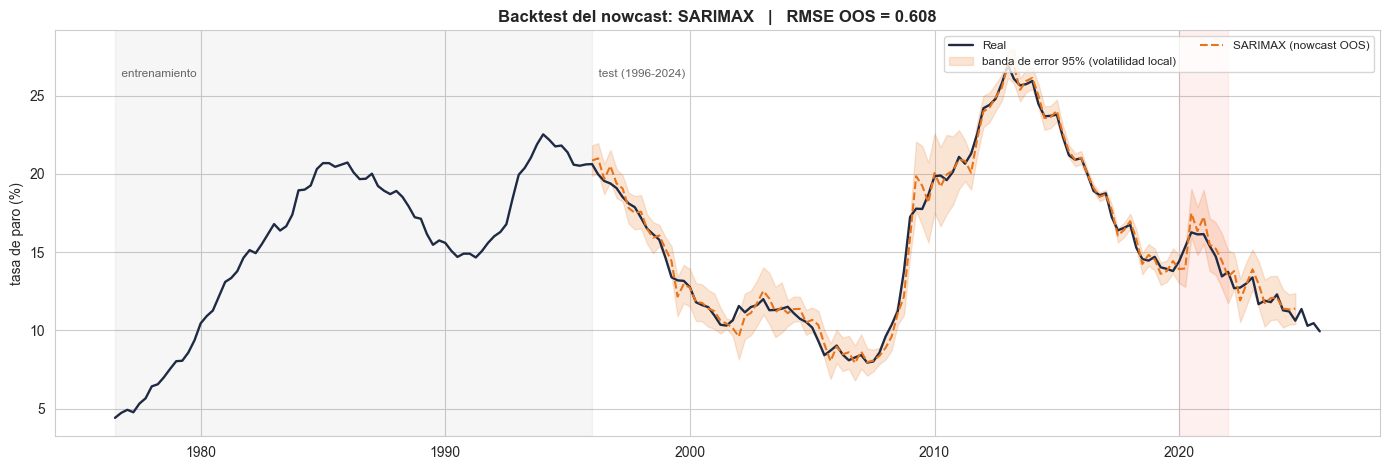

In [16]:
plot_backtest(preds_sx, "SARIMAX", C["sarimax"])

In [17]:
# Frecuencia de selección de cada exógena a lo largo de los folds (qué eligió la búsqueda, solo train)
frec = Counter(c for fila in sel_sx["exog"] for c in fila)
frec_tabla = (pd.DataFrame({"variable": list(frec), "folds": list(frec.values())})
              .sort_values("folds", ascending=False)
              .assign(frac=lambda t: (t["folds"] / len(sel_sx)).round(2))
              .reset_index(drop=True))
frec_tabla.head(15)

,variable,folds,frac
0,brecha_output_hp,116,1.00
1,crecimiento_credito_yoy,116,1.00
2,inflacion_qoq,116,1.00
3,vab_agricultura,116,1.00
4,tasa_inversion,116,1.00
5,crecimiento_pib_yoy,84,0.72
6,consumo_publico,44,0.38
7,vab_construccion,40,0.34
8,dummy_2020Q2,16,0.14
9,crecimiento_pib_qoq,12,0.10


**Lectura del SARIMAX.** El modelo con exógenas bate al paseo aleatorio en todos los horizontes, con
una mejora de RMSE entre el 22.3% en el nowcast y el 9.8% a cuatro trimestres, pero no mejora al ARIMA
univariante: queda por debajo en los cinco horizontes, con un skill frente al benchmark entre -0.052 y
-0.160. La lectura honesta, anticipada en el handoff del proyecto, es que la información
macroeconómica del panel no añade capacidad predictiva sobre la propia inercia de la serie a estos
horizontes. No por ello se descarta del ensamblaje: un modelo con errores poco correlacionados con los
del benchmark puede mejorar la combinación.

La frecuencia de selección confirma las banderas amarillas que el panel dejó marcadas. `vab_agricultura`
y `tasa_inversion` se eligen en el 100% de los folds, igual que el núcleo económico forzado, pero esa
dominancia en muestra no se traduce en ganancia fuera de muestra, que es precisamente la sospecha de
ajuste en muestra del panel. El crecimiento del PIB interanual entra en el 72% de los folds, coherente
con el canal de Okun, y la dummy de 2020 solo en el 14%, cuando 2020-Q2 ya forma parte del
entrenamiento.

En el stress-test COVID el SARIMAX se degrada algo más que el paseo aleatorio a horizontes largos, con
un RMSE de entre 2.03 y 3.05 en los horizontes 1 a 4 frente a entre 1.28 y 1.77 del paseo aleatorio:
las exógenas, ajustadas a la relación normal entre actividad y empleo, desorientan durante un shock que
rompe esa relación.

## 7. Comparativa y stress-test COVID

Tabla conjunta de los tres modelos por horizonte y subperiodo COVID, RMSE por horizonte y trayectoria
del backtest para ver qué modelos se rompen con la COVID y cuáles se recuperan. Estas predicciones
quedan guardadas en `Resultados/` para el cuaderno de comparación y ensamblaje, que las consume sin
reejecutar.

In [18]:
def fila_resumen(nombre, preds, met):
    """Fila de la tabla comparativa: RMSE por horizonte, global y subperiodo COVID de un modelo."""
    f = {"modelo": nombre}
    for h in HORIZONTES:
        f[f"rmse_h{h}"] = round(met["por_horizonte"][str(h)]["rmse"], 3)
    f["rmse_global"] = round(met["global"]["rmse"], 3)
    err = preds["y_real"] - preds["y_pred"]
    covid = err[preds["fecha"].astype(str).str.match(r"20(20|21)Q")]
    f["rmse_covid"] = round(_rmse(covid.to_numpy()), 3)
    return f


resumen = pd.DataFrame([
    fila_resumen("Random Walk", preds_rw, met_rw),
    fila_resumen("ARIMA", preds_ar, met_ar),
    fila_resumen("SARIMAX", preds_sx, met_sx),
]).set_index("modelo")
resumen

,rmse_h0,rmse_h1,rmse_h2,rmse_h3,rmse_h4,rmse_global,rmse_covid
modelo,,,,,,,
Random Walk,0.783,1.330,1.776,2.205,2.709,1.883,1.501
ARIMA,0.524,0.990,1.414,1.790,2.295,1.531,2.288
SARIMAX,0.608,1.077,1.500,1.883,2.442,1.630,2.308


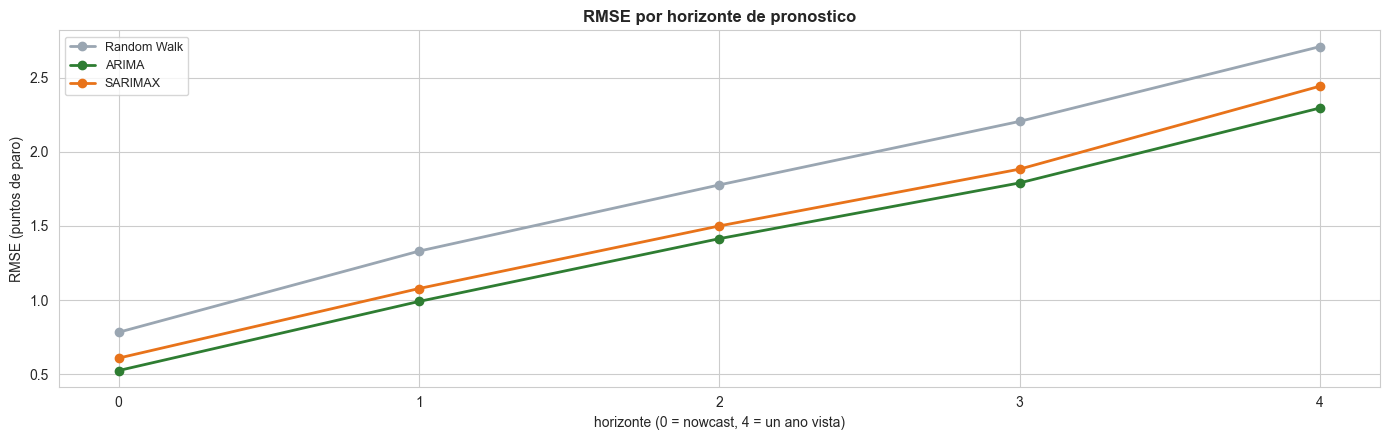

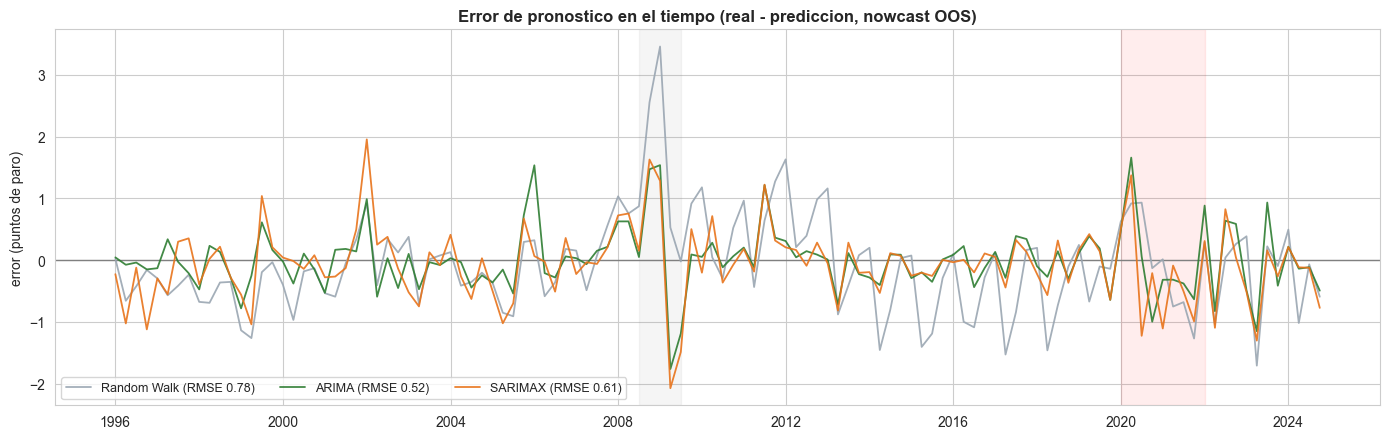

In [19]:
# RMSE por horizonte de los tres modelos (unico grafico donde la comparacion directa aporta)
plot_rmse_horizonte([("Random Walk", met_rw, C["rw"]),
                     ("ARIMA", met_ar, C["arima"]),
                     ("SARIMAX", met_sx, C["sarimax"])])

# Vista de conjunto: error de cada modelo en el tiempo (donde fallan, sin sobreajuste)
plot_errores([("Random Walk", preds_rw, C["rw"]),
              ("ARIMA", preds_ar, C["arima"]),
              ("SARIMAX", preds_sx, C["sarimax"])])

**Lectura de la comparativa y el stress-test.** En condiciones normales el orden es nítido: el ARIMA
univariante es el mejor modelo único, con el menor RMSE global (1.531) y la mejor cifra o un empate en
cada horizonte. El SARIMAX (1.630) bate al suelo pero no al benchmark, y el paseo aleatorio (1.883)
queda por debajo de ambos.

El stress-test invierte el orden. Durante la COVID el paseo aleatorio es el más robusto (RMSE 1.501) y
tanto el ARIMA (2.288) como el SARIMAX (2.308) se degradan más. La razón es estructural: ante un shock
sin precedente, arrastrar el último valor conocido erra menos que un modelo que proyecta una dinámica
o unas relaciones ajustadas al régimen anterior. La dummy 2020-Q2 limpia el atípico para los folds
posteriores, pero no ayuda a pronosticar el propio shock, que es el sentido del ejercicio. Para el
cuaderno de ensamblaje, esto sugiere que el paseo aleatorio aporta diversidad valiosa en los tramos de
crisis, donde los modelos más estructurados fallan.

### 7.1 Diagnostico de heterocedasticidad (ARCH-LM)

La primera diferencia de la tasa de paro esta fichada en el EDA como heterocedasticidad de tipo 2 (clusters de volatilidad). Se contrasta formalmente con el test ARCH-LM de Engle sobre los residuos en muestra del ARIMA.

In [20]:
# test ARCH-LM de Engle sobre los residuos en muestra del ARIMA
from statsmodels.stats.diagnostic import het_arch
_o, _s, _t = buscar_orden(y)
_resid = np.asarray(ajustar_sarimax(y, None, _o, _s, _t).resid)
_lm, _lmp, _f, _fp = het_arch(_resid, nlags=4)
print(f"ARCH-LM (4 rezagos): estadistico = {_lm:.2f}   p-valor = {_lmp:.4g}")
print("Rechaza homocedasticidad" if _lmp < 0.05 else "No rechaza homocedasticidad")

ARCH-LM (4 rezagos): estadistico = 32.81   p-valor = 1.305e-06
Rechaza homocedasticidad


**Lectura del ARCH-LM.** El contraste rechaza la homocedasticidad, como anticipaba el EDA. Ese rechazo no implica un proceso GARCH autonomo: recoge sobre todo el efecto de regimen (varianza alta en 1992-1994 y 2008-2013, baja en 1997-2007) y un par de trimestres atipicos (2008-2009 y la COVID, esta ultima ya aislada como caso aparte). Es heterocedasticidad de regimen y ruptura, no una dinamica que justifique un modelo de volatilidad. La consecuencia practica no es estimar un GARCH sino reconocer que los intervalos de prediccion honestos deben ensancharse en los regimenes volatiles, lo que recogen las bandas de error de volatilidad local de los backtests.

## 8. Evolución esperada del paro

El benchmark ARIMA, reestimado sobre la muestra completa, proyecta los próximos cuatro trimestres con
sus bandas de confianza. Es la vista de cómo se espera que evolucione el paro. El SARIMAX no puede
proyectar más allá del último dato sin valores futuros de los regresores, así que la vista a futuro
es univariante; las exógenas aportan en el nowcast y el corto plazo dentro de la muestra, donde sí
están disponibles.

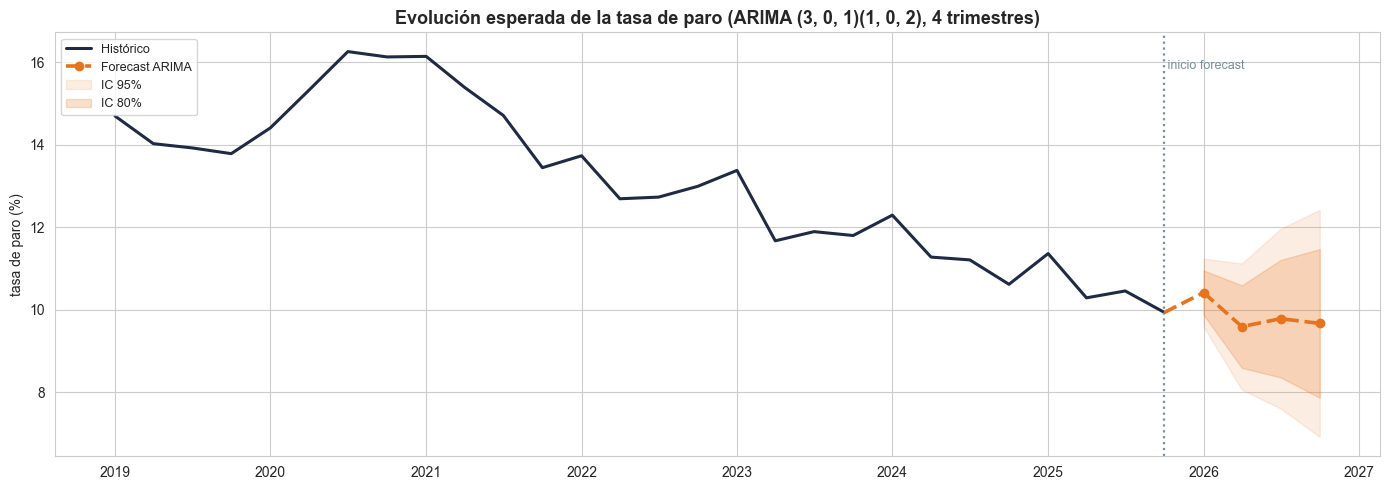

,trimestre,forecast,IC80_inf,IC80_sup
0,2026Q1,10.41,9.87,10.95
1,2026Q2,9.59,8.59,10.59
2,2026Q3,9.78,8.36,11.20
3,2026Q4,9.67,7.86,11.47


In [21]:
order_f, seas_f, trend_f = buscar_orden(y)            # orden sobre la muestra completa, solo para proyectar
res_f = ajustar_sarimax(y, None, order_f, seas_f, trend_f)
H = 4
fc = res_f.get_forecast(steps=H)
media, ci80, ci95 = fc.predicted_mean, fc.conf_int(alpha=0.20), fc.conf_int(alpha=0.05)
idx_fut = pd.period_range(y.index[-1] + 1, periods=H, freq="Q").to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
cola = y.iloc[-28:]
ax.plot(cola.index.to_timestamp(), cola.values, color=C["real"], lw=2.2, label="Histórico")
ax.plot([cola.index.to_timestamp()[-1], idx_fut[0]], [cola.values[-1], media.values[0]],
        color=C["sarimax"], lw=2.6, ls="--")
ax.plot(idx_fut, media.values, color=C["sarimax"], lw=2.6, ls="--", marker="o", label="Forecast ARIMA")
ax.fill_between(idx_fut, ci95.iloc[:, 0], ci95.iloc[:, 1], color=C["band"], alpha=0.12, label="IC 95%")
ax.fill_between(idx_fut, ci80.iloc[:, 0], ci80.iloc[:, 1], color=C["band"], alpha=0.22, label="IC 80%")
ax.axvline(cola.index.to_timestamp()[-1], color=C["corte"], ls=":", lw=1.6)
ax.text(cola.index.to_timestamp()[-1], ax.get_ylim()[1] * 0.96, " inicio forecast",
        color=C["corte"], fontsize=9, va="top")
ax.set_title(f"Evolución esperada de la tasa de paro (ARIMA {order_f}{seas_f[:3]}, 4 trimestres)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("tasa de paro (%)"); ax.legend(fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

pd.DataFrame({"trimestre": [str(p) for p in pd.period_range(y.index[-1] + 1, periods=H, freq="Q")],
              "forecast": media.values.round(2),
              "IC80_inf": ci80.iloc[:, 0].values.round(2), "IC80_sup": ci80.iloc[:, 1].values.round(2)})

In [23]:
pd.DataFrame({'trimestre': ["2026Q1", "2026Q2", "2026Q3", "2026Q4"],  # cuatro trimestres posteriores al ultimo dato (2025Q4)
              'forecast': media.values.round(2),
              'IC80_inf': ci80.iloc[:, 0].values.round(2), 'IC80_sup': ci80.iloc[:, 1].values.round(2),
              'IC95_inf': ci95.iloc[:, 0].values.round(2), 'IC95_sup': ci95.iloc[:, 1].values.round(2)}
            ).to_csv(RUTA_RESULTADOS / 'proyeccion_futura_arima.csv', index=False)
print('guardado: proyeccion_futura_arima.csv')

guardado: proyeccion_futura_arima.csv


## 9. Cierre

Quedan guardados en `Resultados/` los tres pares `preds_<modelo>.csv` y `metricas_<modelo>.json` para
`random_walk`, `arima` y `sarimax`, con el suelo y el benchmark que el resto de cuadernos cargarán.
Cada fichero de métricas incluye RMSE y MAE por horizonte, global y subperiodo COVID, más el skill
score frente al paseo aleatorio y, en el SARIMAX, frente al ARIMA.

**Checkpoint de honestidad.**

- **Hecho.** Suelo (paseo aleatorio), benchmark (ARIMA univariante) y SARIMAX evaluados en 116 folds
  del expanding window, de 1996-Q1 a 2024-Q4, con salida guardada. El ARIMA es el mejor modelo único de
  esta familia, con RMSE global 1.531 y la mejor cifra o un empate en los cinco horizontes.
- **Qué no mejora.** Las exógenas del panel no baten al econométrico simple a ningún horizonte, con un
  skill frente al ARIMA de entre -0.052 y -0.160. No se descartan del ensamblaje por la diversidad de
  errores que pueden aportar.
- **Stress-test.** En la COVID el paseo aleatorio es el más robusto y ambos modelos econométricos se
  degradan, un resultado esperado y útil para la combinación de pronósticos.
- **Limitaciones declaradas.** (1) El gridsearch se acota por parsimonia y se apoya en una guarda de
  estabilidad, que se activa en un fold del ARIMA; un orden de orden alto minimiza el AICc en muestra
  pero no mejora de forma fiable fuera de muestra. (2) El SARIMAX reutiliza el orden ARMA del benchmark
  de cada fold en lugar de rebuscarlo con exógenas. (3) El cribado forward de exógenas se hace sobre la
  media condicional y el modelo final es un SARIMAX completo. (4) El benchmark univariante no controla
  2020, así que el atípico contamina los folds posteriores, a diferencia del SARIMAX.